## Datos de Apophis

### Fundamento Teórico del Modelo de N-Cuerpos

Este notebook implementa la resolución numérica del **problema de N-cuerpos** en el marco de la mecánica celeste newtoniana, utilizando condiciones iniciales reales obtenidas del servicio JPL Horizons (NASA) para el Sol, la Tierra, la Luna, Júpiter y el asteroide Apophis.

#### 1. Ecuaciones de Movimiento 

El modelo se basa en la Ley de Gravitación Universal. Para un sistema de $N$ partículas, la aceleración de un cuerpo $i$ debida a la influencia gravitatoria de todos los demás cuerpos $j$ está dada por:

$$\frac{d^2\mathbf{r}_i}{dt^2} = -G \sum_{j \neq i}^{N} m_j \frac{\mathbf{r}_i - \mathbf{r}_j}{\|\mathbf{r}_i - \mathbf{r}_j\|^3}$$

Donde:
* $\mathbf{r}_i$: Vector de posición del cuerpo $i$.
* $G$: Constante de gravitación universal.
* $(\mathbf{r}_i - \mathbf{r}_j)$: Vector que define la dirección de la fuerza, apuntando desde el cuerpo $j$ hacia el cuerpo $i$.



#### 2. Unidades Canónicas y Normalización

Para mejorar la estabilidad numérica y evitar errores de precisión al trabajar con órdenes de magnitud extremos (como $10^{30}$ kg o $10^{11}$ m), el código transforma las magnitudes del Sistema Internacional (SI) a **unidades canónicas**:

* **Unidad de Longitud ($UL$):** $1$ Unidad Astronómica (AU).
* **Unidad de Masa ($UM$):** $1$ Masa Solar ($M_{\odot}$).
* **Unidad de Tiempo ($UT$):** Se define mediante la tercera ley de Kepler, de modo que la constante gravitacional en el sistema simulación sea $G_c = 1$.

#### 3. Integración Numérica: Algoritmo IAS15

La dinámica se integra con `IAS15` (REBOUND), un integrador adaptativo de alta precisión apropiado para problemas gravitacionales con escalas temporales muy distintas (la Luna orbita la Tierra en 27 días, mientras Júpiter tarda 12 años).

#### 4. Energía Mecánica Total del Sistema

La energía total $E$ se calcula:

$$E = K + U$$

* **Energía Cinética ($K$):** $$K = \frac{1}{2} \sum_{i} m_i \|\mathbf{v}_i\|^2$$
* **Energía Potencial Gravitatoria ($U$):** $$U = -\sum_{i < j} \frac{G_c m_i m_j}{\|\mathbf{r}_i - \mathbf{r}_j\|}$$

#### 5. Referencial Baricéntrico

El código utiliza la función `sim.move_to_com()` para trasladar el origen de coordenadas al **Centro de Masa (Baricentro)** del sistema:
$$\mathbf{R}_{COM} = \frac{\sum m_i \mathbf{r}_i}{\sum m_i}$$
Esto asegura que el sistema no presente un desplazamiento del sistema completo a través del espacio debido a errores numéricos o a una mala elección del sistema de referencia.

Unidades canonicas:
  UL = 1.495979e+11 m
  UM = 1.988470e+30 kg
  UT = 5.022567e+06 s
  Gc = 1


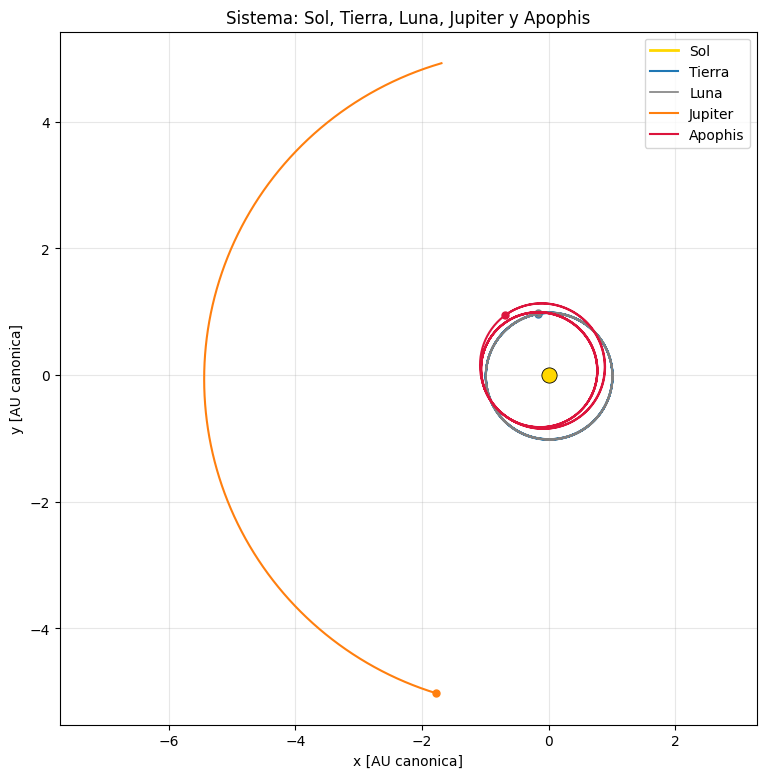

Energia cinetica (canonicas): 8.882309e-05
Energia potencial (canonicas): -1.820769e-04
Energia total del sistema (canonicas): -9.325378e-05


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import rebound
import pymcel as pc


# Datos desde Horizons
epochs = '2026-01-01 00:00:00'

# Propiedades solicitadas a Horizons en unidades SI
propiedades = [
    ('x', 'm'), ('y', 'm'), ('z', 'm'),
    ('vx', 'm/s'), ('vy', 'm/s'), ('vz', 'm/s')
]

# Lista de cuerpos: (nombre_en_simulacion, id_horizons)
cuerpos = [
    ('Sol', '10'),
    ('Tierra', '399'),
    ('Luna', '301'),
    ('Jupiter', '599'),
    ('Apophis', '99942'),
]

# Masas en SI [kg]
masas_si = {
    'Sol': 1.98847e30,
    'Tierra': 5.9722e24,
    'Luna': 7.34767309e22,
    'Jupiter': 1.89813e27,
    'Apophis': 3.4e10,
}

# Diccionario para almacenar los vectores de estado en SI por cuerpo
estados_si = {}
for nombre, obj_id in cuerpos:
    # consulta_horizons devuelve la salida de Horizons para el cuerpo solicitado
    tabla, ts, salida = pc.consulta_horizons(
        id=obj_id,
        location='@0',   # centro en Sol
        datos='vectors',
        propiedades=propiedades,
        epochs=epochs,
    )
    # salida contiene [x, y, z, vx, vy, vz]
    estados_si[nombre] = np.array(salida, dtype=float).reshape(-1)

# Unidades canonicas (AU, Msun)
UL = 1.495978707e11   # 1 AU en metros
UM = 1.98847e30       # 1 Msun en kg
UL, UM, UT, Gc = pc.unidades_canonicas(UL=UL, UM=UM)  # Gc = 1

# Unidad de velocidad canonica
vel_unit = UL / UT

# Conversion SI -> canonico
estados_can = {}
for nombre, vec in estados_si.items():
    x, y, z, vx, vy, vz = vec
    estados_can[nombre] = np.array([
        x / UL,
        y / UL,
        z / UL,
        vx / vel_unit,
        vy / vel_unit,
        vz / vel_unit,
    ])

# Conversion de masas a unidad de masa canonica
masas_can = {nombre: masas_si[nombre] / UM for nombre, _ in cuerpos}

print('Unidades canonicas:')
print(f'  UL = {UL:.6e} m')
print(f'  UM = {UM:.6e} kg')
print(f'  UT = {UT:.6e} s')
print(f'  Gc = {Gc}')

# Simulacion con REBOUND
sim = rebound.Simulation()
sim.integrator = 'ias15'  # Integrador adaptativo de alta precision
sim.G = Gc                

# Agregamos cada cuerpo con su masa, posicion y velocidad inicial
for nombre, _ in cuerpos:
    x, y, z, vx, vy, vz = estados_can[nombre]
    sim.add(
        m=masas_can[nombre],
        x=x,
        y=y,
        z=z,
        vx=vx,
        vy=vy,
        vz=vz,
        hash=nombre,
    )

# Recentramos al sistema de referencia del centro de masa
sim.move_to_com()

# Tiempo total de integracion: 5 años
tmax_years = 5.0
tmax_si = tmax_years * 365.25 * 24 * 3600.0
tmax_can = tmax_si / UT

# Numero de pasos
N = 1200
times = np.linspace(0.0, tmax_can, N)

# Nombres de cuerpos y contenedor para trayectorias en el plano (x,y)
names = [nombre for nombre, _ in cuerpos]
coords = {name: np.zeros((N, 2)) for name in names}

# Integramos y guardamos posiciones en cada instante
for i, t in enumerate(times):
    sim.integrate(t)
    for name in names:
        p = sim.particles[name]
        coords[name][i, 0] = p.x
        coords[name][i, 1] = p.y

#Grafica de trayectorias

plt.figure(figsize=(9, 9))
styles = {
    'Sol': dict(color='gold', lw=2.0),
    'Tierra': dict(color='tab:blue', lw=1.5),
    'Luna': dict(color='gray', lw=1.2),
    'Jupiter': dict(color='tab:orange', lw=1.5),
    'Apophis': dict(color='crimson', lw=1.5),
}

for name in names:
    # Curva completa y marcador de posicion final
    plt.plot(coords[name][:, 0], coords[name][:, 1], label=name, **styles[name])
    plt.scatter(coords[name][-1, 0], coords[name][-1, 1], s=25, color=styles[name]['color'])

plt.scatter(0, 0, color='gold', s=120, edgecolor='black', linewidth=0.6, zorder=5)
plt.title('Sistema: Sol, Tierra, Luna, Jupiter y Apophis')
plt.xlabel('x [AU canonica]')
plt.ylabel('y [AU canonica]')
plt.axis('equal')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Energia total en unidades canonicas: E = T + U
particulas = sim.particles
masas = np.array([p.m for p in particulas])
velocidades = np.array([[p.vx, p.vy, p.vz] for p in particulas])
posiciones = np.array([[p.x, p.y, p.z] for p in particulas])

# Energia cinetica
T = 0.5 * np.sum(masas * np.sum(velocidades**2, axis=1))

# Energia potencial 
U = 0.0
npart = len(particulas)
for i in range(npart):
    for j in range(i + 1, npart):
        ri = posiciones[i]
        rj = posiciones[j]
        rij = ri - rj                     
        dist_ij = np.linalg.norm(rij)     
        U += -Gc * masas[i] * masas[j] / dist_ij

# Energia total del sistema
E_total = T + U

print(f'Energia cinetica (canonicas): {T:.6e}')
print(f'Energia potencial (canonicas): {U:.6e}')
print(f'Energia total del sistema (canonicas): {E_total:.6e}')

### Cálculo incluyendo a Urano

En esta celda se repite el procedimiento del modelo N-cuerpos, pero ahora se agrega **Urano** al sistema para evaluar su efecto en la energía cinética, potencial y total.

Sistema con Urano
Energia cinetica (canonicas): 8.996688e-05
Energia potencial (canonicas): -1.843581e-04
Energia total del sistema (canonicas): -9.439125e-05


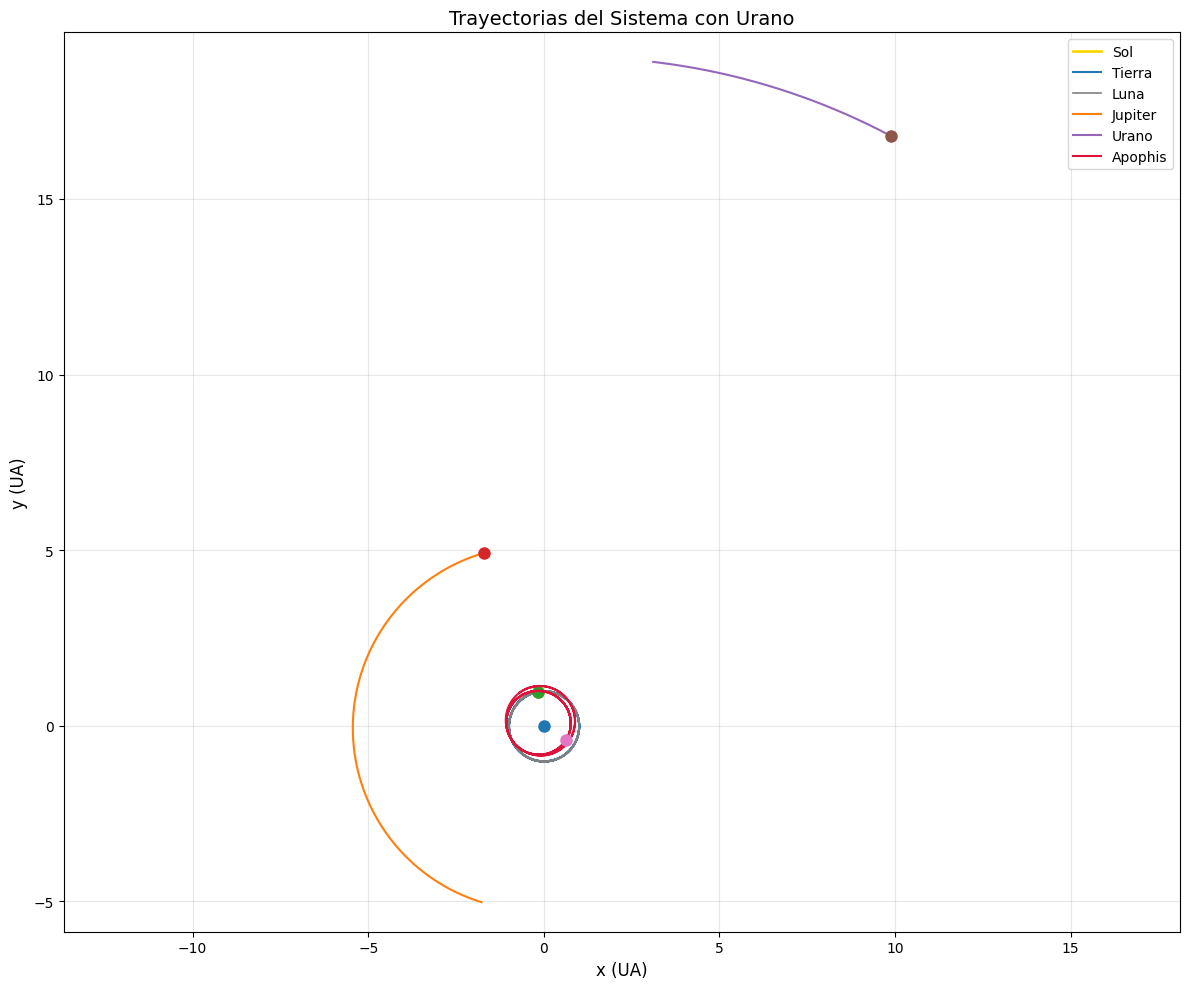

In [10]:
epochs_u = '2026-01-01 00:00:00'
propiedades_u = [('x', 'm'), ('y', 'm'), ('z', 'm'), ('vx', 'm/s'), ('vy', 'm/s'), ('vz', 'm/s')]

# Cuerpos del sistema, ahora incluyendo Urano (ID Horizons = 799)
cuerpos_u = [
    ('Sol', '10'),
    ('Tierra', '399'),
    ('Luna', '301'),
    ('Jupiter', '599'),
    ('Urano', '799'),
    ('Apophis', '99942'),
]

# Masas en SI [kg], incluyendo Urano
masas_si_u = {
    'Sol': 1.98847e30,
    'Tierra': 5.9722e24,
    'Luna': 7.34767309e22,
    'Jupiter': 1.89813e27,
    'Urano': 8.6810e25,
    'Apophis': 3.4e10,
}

# 1) Consulta de condiciones iniciales en SI
estados_si_u = {}
for nombre, obj_id in cuerpos_u:
    tabla, ts, salida = pc.consulta_horizons(
        id=obj_id,
        location='@0',
        datos='vectors',
        propiedades=propiedades_u,
        epochs=epochs_u,
    )
    estados_si_u[nombre] = np.array(salida, dtype=float).reshape(-1)

# 2) Unidades canonicas y conversion de estados
UL_u = 1.495978707e11
UM_u = 1.98847e30
UL_u, UM_u, UT_u, Gc_u = pc.unidades_canonicas(UL=UL_u, UM=UM_u)
vel_unit_u = UL_u / UT_u

estados_can_u = {}
for nombre, vec in estados_si_u.items():
    x, y, z, vx, vy, vz = vec
    estados_can_u[nombre] = np.array([
        x / UL_u,
        y / UL_u,
        z / UL_u,
        vx / vel_unit_u,
        vy / vel_unit_u,
        vz / vel_unit_u,
    ])

masas_can_u = {nombre: masas_si_u[nombre] / UM_u for nombre, _ in cuerpos_u}

# 3) Simulacion REBOUND
sim_u = rebound.Simulation()
sim_u.integrator = 'ias15'
sim_u.G = Gc_u

for nombre, _ in cuerpos_u:
    x, y, z, vx, vy, vz = estados_can_u[nombre]
    sim_u.add(
        m=masas_can_u[nombre],
        x=x,
        y=y,
        z=z,
        vx=vx,
        vy=vy,
        vz=vz,
        hash=nombre,
    )

sim_u.move_to_com()

# 4) Integracion temporal (5 anios, como en el caso base)
tmax_years_u = 5.0
tmax_si_u = tmax_years_u * 365.25 * 24 * 3600.0
tmax_can_u = tmax_si_u / UT_u

N_u = 1200
times_u = np.linspace(0.0, tmax_can_u, N_u)
for t in times_u:
    sim_u.integrate(t)

# 5) Energia mecanica total: E = T + U
particulas_u = sim_u.particles
masas_u = np.array([p.m for p in particulas_u])
velocidades_u = np.array([[p.vx, p.vy, p.vz] for p in particulas_u])
posiciones_u = np.array([[p.x, p.y, p.z] for p in particulas_u])

# Energia cinetica
T_u = 0.5 * np.sum(masas_u * np.sum(velocidades_u**2, axis=1))

# Energia potencial usando notacion del curso: r_i - r_j
U_u = 0.0
npart_u = len(particulas_u)
for i in range(npart_u):
    for j in range(i + 1, npart_u):
        ri = posiciones_u[i]
        rj = posiciones_u[j]
        rij = ri - rj
        dist_ij = np.linalg.norm(rij)
        U_u += -Gc_u * masas_u[i] * masas_u[j] / dist_ij

E_total_u = T_u + U_u

print('Sistema con Urano')
print(f'Energia cinetica (canonicas): {T_u:.6e}')
print(f'Energia potencial (canonicas): {U_u:.6e}')
print(f'Energia total del sistema (canonicas): {E_total_u:.6e}')

# Grafica de trayectorias
fig, ax = plt.subplots(figsize=(12, 10))

for nombre, _ in cuerpos_u:
    # Extraer posiciones durante la simulacion
    traj = []
    sim_u = rebound.Simulation()
    sim_u.integrator = 'ias15'
    sim_u.G = Gc_u
    
    for n, _ in cuerpos_u:
        x, y, z, vx, vy, vz = estados_can_u[n]
        sim_u.add(m=masas_can_u[n], x=x, y=y, z=z, vx=vx, vy=vy, vz=vz, hash=n)
    
    sim_u.move_to_com()
    
    for t in times_u:
        sim_u.integrate(t)
        p = sim_u.particles[nombre]
        traj.append([p.x, p.y])
    
    traj = np.array(traj)
    ax.plot(traj[:, 0], traj[:, 1], label=nombre, **styles.get(nombre, {}))
    ax.plot(traj[0, 0], traj[0, 1], 'o', markersize=8)

ax.set_xlabel('x (UA)', fontsize=12)
ax.set_ylabel('y (UA)', fontsize=12)
ax.set_title('Trayectorias del Sistema con Urano', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.axis('equal')
plt.tight_layout()
plt.show()


Sistema con todos los planetas (celda aparte)
Energia cinetica (canonicas): 1.093476e-04
Energia potencial (canonicas): -2.215985e-04
Energia total del sistema (canonicas): -1.122509e-04


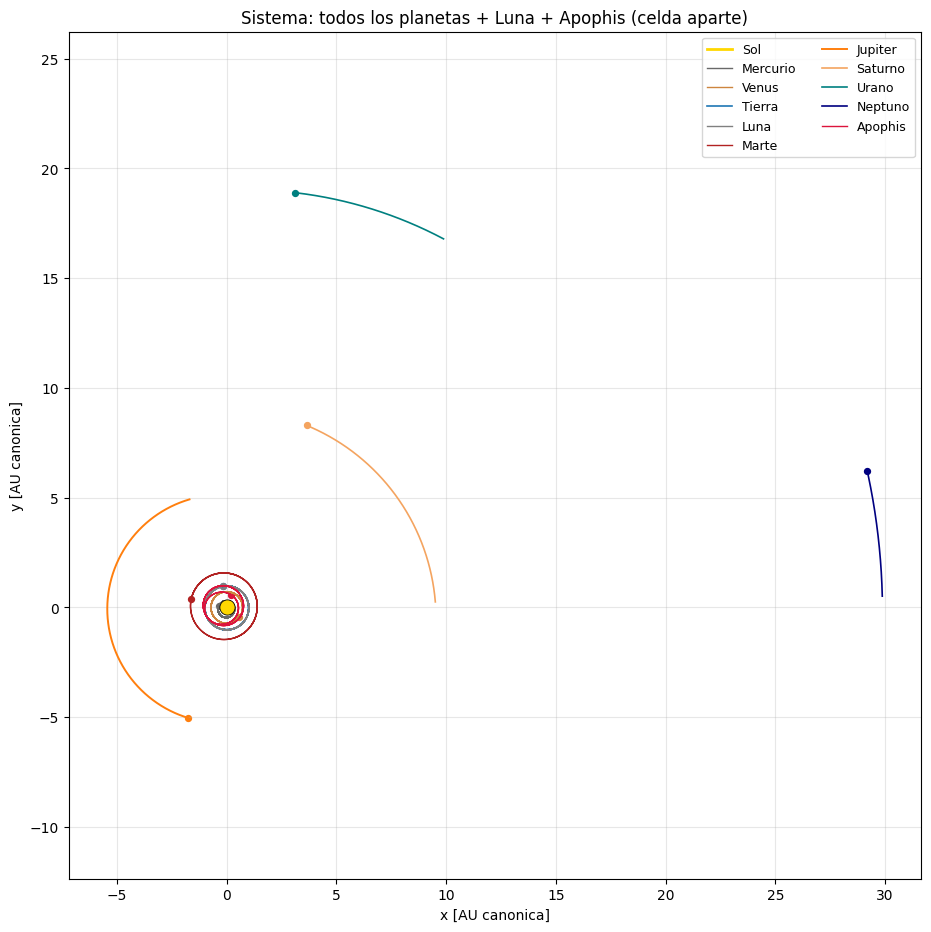

In [ ]:
# Todos los planetas

# Epoca y propiedades para consultar a Horizons
epochs_all = '2026-01-01 00:00:00'
propiedades_all = [('x', 'm'), ('y', 'm'), ('z', 'm'), ('vx', 'm/s'), ('vy', 'm/s'), ('vz', 'm/s')]

# Sol + 8 planetas + Luna + Apophis
cuerpos_all = [
    ('Sol', '10'),
    ('Mercurio', '199'),
    ('Venus', '299'),
    ('Tierra', '399'),
    ('Luna', '301'),
    ('Marte', '499'),
    ('Jupiter', '599'),
    ('Saturno', '699'),
    ('Urano', '799'),
    ('Neptuno', '899'),
    ('Apophis', '99942'),
]

# Masas en SI [kg]
masas_si_all = {
    'Sol': 1.98847e30,
    'Mercurio': 3.3011e23,
    'Venus': 4.8675e24,
    'Tierra': 5.9722e24,
    'Luna': 7.34767309e22,
    'Marte': 6.4171e23,
    'Jupiter': 1.89813e27,
    'Saturno': 5.6834e26,
    'Urano': 8.6810e25,
    'Neptuno': 1.02413e26,
    'Apophis': 3.4e10,
}

# 1) Consulta de estados iniciales en SI
estados_si_all = {}
for nombre, obj_id in cuerpos_all:
    tabla, ts, salida = pc.consulta_horizons(
        id=obj_id,
        location='@0',
        datos='vectors',
        propiedades=propiedades_all,
        epochs=epochs_all,
    )
    estados_si_all[nombre] = np.array(salida, dtype=float).reshape(-1)

# 2) Conversion a unidades canonicas
UL_all = 1.495978707e11
UM_all = 1.98847e30
UL_all, UM_all, UT_all, Gc_all = pc.unidades_canonicas(UL=UL_all, UM=UM_all)
vel_unit_all = UL_all / UT_all

estados_can_all = {}
for nombre, vec in estados_si_all.items():
    x, y, z, vx, vy, vz = vec
    estados_can_all[nombre] = np.array([
        x / UL_all,
        y / UL_all,
        z / UL_all,
        vx / vel_unit_all,
        vy / vel_unit_all,
        vz / vel_unit_all,
    ])

masas_can_all = {nombre: masas_si_all[nombre] / UM_all for nombre, _ in cuerpos_all}

# 3) Simulacion
sim_all = rebound.Simulation()
sim_all.integrator = 'ias15'
sim_all.G = Gc_all

for nombre, _ in cuerpos_all:
    x, y, z, vx, vy, vz = estados_can_all[nombre]
    sim_all.add(m=masas_can_all[nombre], x=x, y=y, z=z, vx=vx, vy=vy, vz=vz, hash=nombre)

sim_all.move_to_com()

# 4) Integracion y trayectorias
tmax_years_all = 5.0
tmax_si_all = tmax_years_all * 365.25 * 24 * 3600.0
tmax_can_all = tmax_si_all / UT_all
N_all = 1200
times_all = np.linspace(0.0, tmax_can_all, N_all)

names_all = [nombre for nombre, _ in cuerpos_all]
coords_all = {name: np.zeros((N_all, 2)) for name in names_all}

for i, t in enumerate(times_all):
    sim_all.integrate(t)
    for name in names_all:
        p = sim_all.particles[name]
        coords_all[name][i, 0] = p.x
        coords_all[name][i, 1] = p.y

# 5) Energia: E = T + U
particulas_all = sim_all.particles
masas_all = np.array([p.m for p in particulas_all])
velocidades_all = np.array([[p.vx, p.vy, p.vz] for p in particulas_all])
posiciones_all = np.array([[p.x, p.y, p.z] for p in particulas_all])

T_all = 0.5 * np.sum(masas_all * np.sum(velocidades_all**2, axis=1))

U_all = 0.0
npart_all = len(particulas_all)
for i in range(npart_all):
    for j in range(i + 1, npart_all):
        ri = posiciones_all[i]
        rj = posiciones_all[j]
        rij = ri - rj
        dist_ij = np.linalg.norm(rij)
        U_all += -Gc_all * masas_all[i] * masas_all[j] / dist_ij

E_total_all = T_all + U_all

print('Sistema con todos los planetas (celda aparte)')
print(f'Energia cinetica (canonicas): {T_all:.6e}')
print(f'Energia potencial (canonicas): {U_all:.6e}')
print(f'Energia total del sistema (canonicas): {E_total_all:.6e}')

# 6) Grafica
styles_all = {
    'Sol': dict(color='gold', lw=2.0),
    'Mercurio': dict(color='dimgray', lw=1.0),
    'Venus': dict(color='peru', lw=1.0),
    'Tierra': dict(color='tab:blue', lw=1.2),
    'Luna': dict(color='gray', lw=1.0),
    'Marte': dict(color='firebrick', lw=1.0),
    'Jupiter': dict(color='tab:orange', lw=1.4),
    'Saturno': dict(color='sandybrown', lw=1.2),
    'Urano': dict(color='teal', lw=1.2),
    'Neptuno': dict(color='navy', lw=1.2),
    'Apophis': dict(color='crimson', lw=1.0),
}

plt.figure(figsize=(11, 11))
for name in names_all:
    plt.plot(coords_all[name][:, 0], coords_all[name][:, 1], label=name, **styles_all[name])
    plt.scatter(coords_all[name][-1, 0], coords_all[name][-1, 1], s=18, color=styles_all[name]['color'])

plt.scatter(0, 0, color='gold', s=120, edgecolor='black', linewidth=0.6, zorder=5)
plt.title('Sistema: todos los planetas + Luna + Apophis')
plt.xlabel('x [AU canonica]')
plt.ylabel('y [AU canonica]')
plt.axis('equal')
plt.grid(alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.show()

In [ ]:
# Simulacion animada (Plotly) en una celda aparte
import subprocess
import sys

# Instala nbformat si es necesario
try:
    import nbformat
    from packaging import version
    if version.parse(nbformat.__version__) < version.parse("4.2.0"):
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "nbformat"])
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "nbformat"])

try:
    import plotly.graph_objects as go
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly"])
    import plotly.graph_objects as go

# Verifica que existan las variables necesarias
if 'coords_all' not in globals() or 'names_all' not in globals():
    raise RuntimeError(
        "Faltan variables. Ejecuta primero la celda de 'todos los planetas'."
    )

# Paleta de colores RGB (Plotly-compatible)
color_palette = {
    'Sol': '#FFD700',
    'Mercurio': '#808080',
    'Venus': '#8B7355',
    'Tierra': '#1f77b4',
    'Luna': '#A9A9A9',
    'Marte': '#DC143C',
    'Jupiter': '#FF8C00',
    'Saturno': '#F4A460',
    'Urano': '#008080',
    'Neptuno': '#000080',
    'Apophis': '#DC143C',
}

# Muestreo para suavidad de animacion
step = 10
N_total = len(next(iter(coords_all.values())))
indices = np.arange(0, N_total, step)

# Limites del grafico
all_coords = np.concatenate([coords_all[name][indices] for name in names_all], axis=0)
xmin, ymin = all_coords.min(axis=0)
xmax, ymax = all_coords.max(axis=0)
pad = max(xmax - xmin, ymax - ymin) * 0.1

# Datos iniciales para plotly
initial_data = []
for name in names_all:
    x0, y0 = coords_all[name][indices[0]]
    initial_data.append(
        go.Scatter(x=[x0], y=[y0], mode='markers', 
                   name=name, marker=dict(size=8, color=color_palette.get(name, 'black')),
                   showlegend=True)
    )

# Construir frames
frames = []
for idx_val in indices:
    frame_traces = []
    for name in names_all:
        traj_x = coords_all[name][:idx_val+1, 0]
        traj_y = coords_all[name][:idx_val+1, 1]
        
        # Linea de trayectoria
        frame_traces.append(
            go.Scatter(x=traj_x, y=traj_y, mode='lines',
                      line=dict(color=color_palette.get(name, 'black'), width=1),
                      showlegend=False, hoverinfo='skip')
        )
        
        # Posicion actual
        frame_traces.append(
            go.Scatter(x=[traj_x[-1]], y=[traj_y[-1]], mode='markers',
                      marker=dict(size=8, color=color_palette.get(name, 'black')),
                      showlegend=False, hoverinfo='text',
                      text=[name])
        )
    
    frames.append(go.Frame(data=frame_traces, name=str(idx_val)))

# Crear figura
fig = go.Figure(data=initial_data, frames=frames)

# Configuracion
fig.update_layout(
    title='Simulacion: N-cuerpos (Sol, planetas, Luna, Apophis)',
    xaxis_title='x [AU]', yaxis_title='y [AU]',
    xaxis=dict(range=[xmin - pad, xmax + pad], scaleanchor='y', scaleratio=1),
    yaxis=dict(range=[ymin - pad, ymax + pad]),
    width=950, height=950, template='plotly_white',
    updatemenus=[dict(type='buttons', showactive=False,
                     buttons=[dict(label='Play', method='animate',
                                  args=[None, {'frame': {'duration': 50, 'redraw': True}}]),
                             dict(label='Pause', method='animate',
                                  args=[[None], {'frame': {'duration': 0}}])])],
    sliders=[dict(steps=[dict(args=[[str(i)], {'frame': {'duration': 0, 'redraw': True}, 'mode': 'immediate'}], label=f'{j}')
                        for j, i in enumerate(indices)],
                 currentvalue={'prefix': 'Paso: '})]
)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed